## 1. Preprocessing

In [1]:
from preprocessing import run_preprocessing
results= run_preprocessing(
        place_name="Kasarani, Nairobi, Kenya",
        gee_project="causal-bus-404912",
        buffer_m=30,
        gee_buildings_asset="projects/sat-io/open-datasets/MSBuildings/Kenya",
        gee_buildings_local_path="kasarani_buildings_export.geojson",
        raster_local_path="kasarani_sentinel_full_stack.tif",
        output_dir="./output/kasarani",
    )

## 2. Modelling with Random Forest

In [2]:
from modeling import run_modeling

# Encroachment with SPATIAL split (more honest evaluation)
enc_results = run_modeling(
    results["training_table"], 
    results["feature_cols"], 
    results["output_dir"],
    label_col="encroachment", 
    model_name="encroachment_rf", 
    task_type="binary",
    spatial_split=True,   # NEW: block-based split instead of random
)

print("Metrics:", enc_results["metrics"])

c:\Users\Administrator\Documents\DataScience_2026\Capstone_Project_2026\Reparian_enchroachment_Detector\Preprocessing\modeling.py:60: UserWarning: Spatial block split created a single-class subset. Falling back to random stratified split.
  warnings.warn(


Metrics: {'precision': 0.09490616621983915, 'recall': 0.4745308310991957, 'f1': 0.1581769436997319, 'roc_auc': 0.7690976529728593, 'average_precision': 0.14418177460474443, 'baseline_accuracy': 0.96751154080655, 'majority_class': 0, 'class_distribution': {'0': 0.96751154080655, '1': 0.032488459193450045}}


## 3. Evaluation

c:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Saved binary report to output\kasarani\figures\encroachment_rf_report.png
Skipping building_detector_rf: Metadata not found: output\kasarani\models\building_detector_rf_metadata.json
Skipping land_cover_rf: Metadata not found: output\kasarani\models\land_cover_rf_metadata.json


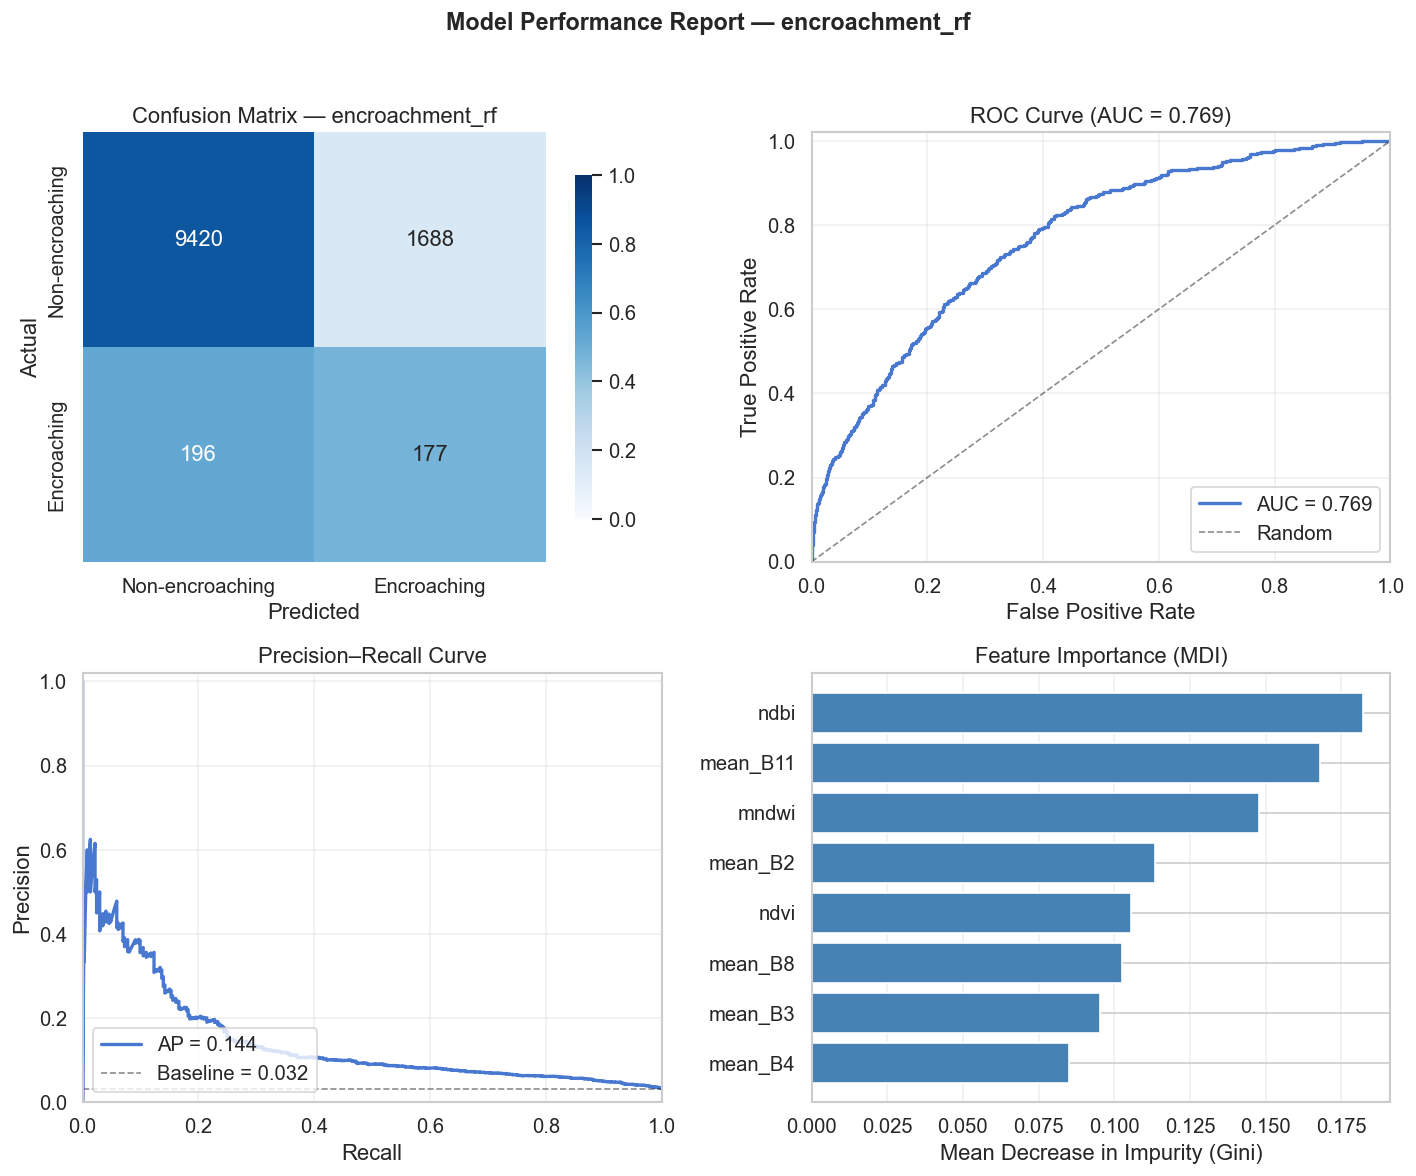

In [4]:
from visualize import build_all_reports

# Auto-discovers encroachment_rf, building_detector_rf, land_cover_rf
# and saves PNGs to ./output/kasarani/figures/
figs = build_all_reports("./output/kasarani")